<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Подбор-параметров" data-toc-modified-id="Подбор-параметров-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Подбор параметров</a></span></li><li><span><a href="#LinearRegression" data-toc-modified-id="LinearRegression-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>LinearRegression</a></span></li><li><span><a href="#CatBoostRegression" data-toc-modified-id="CatBoostRegression-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>CatBoostRegression</a></span></li><li><span><a href="#LightGBMRegression" data-toc-modified-id="LightGBMRegression-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>LightGBMRegression</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [1]:
!pip install category_encoders -q
!pip install scikit-learn==1.1.3 -q

In [2]:
# Все импорты тут:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import lightgbm
from category_encoders.binary import BinaryEncoder
from statsmodels.tsa.seasonal import seasonal_decompose


# Работа с пайплайнами
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# класс для работы с пропусками
from sklearn.impute import SimpleImputer

# Разделение данных на выборки
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit

# Классы для преобразования данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder

# Модели
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import GridSearchCV

# Метрики
from sklearn.metrics import make_scorer, mean_squared_error

# создание константы RANDOM_STATE
RANDOM_STATE = 42

In [3]:
# Открытие данных через конструкцию try-except
try:
    taxi = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

except:
    taxi = pd.read_csv('datasets/taxi.csv', index_col=[0], parse_dates=[0])

In [4]:
taxi.sort_index(inplace=True)

In [5]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [6]:
taxi.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [7]:
taxi = taxi.resample('1H').sum()

## Анализ

In [8]:
date_min = taxi.index.min().strftime('%d.%m.%Y')
date_max = taxi.index.max().strftime('%d.%m.%Y')
print(f'Анализируемый период: c {date_min} - по {date_max}')

Анализируемый период: c 01.03.2018 - по 31.08.2018


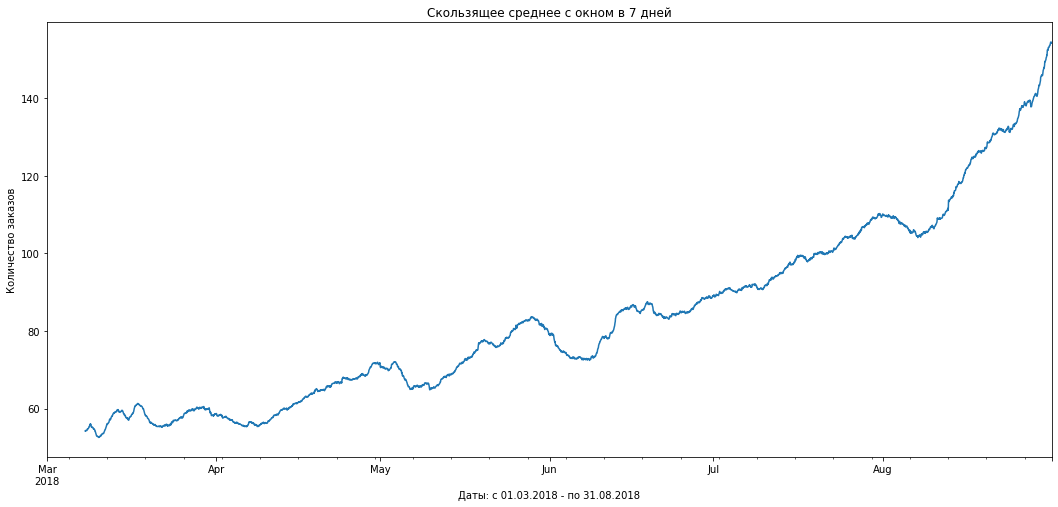

In [9]:
taxi.rolling(24 * 7).mean().plot(figsize=(18, 8), legend=False, ax=plt.gca())
plt.title('Скользящее среднее с окном в 7 дней')
plt.xlabel(f'Даты: c {date_min} - по {date_max}')
plt.ylabel('Количество заказов')
plt.show()

Из построенного графика можно сделать вывод, что в течение года среднее количество заказов за неделю имеет тенденцию к увеличению. К концу рассматриваемого периода (август 2018 года) график достигает своей максимальной отметки.

In [10]:
decomposed = seasonal_decompose(taxi)

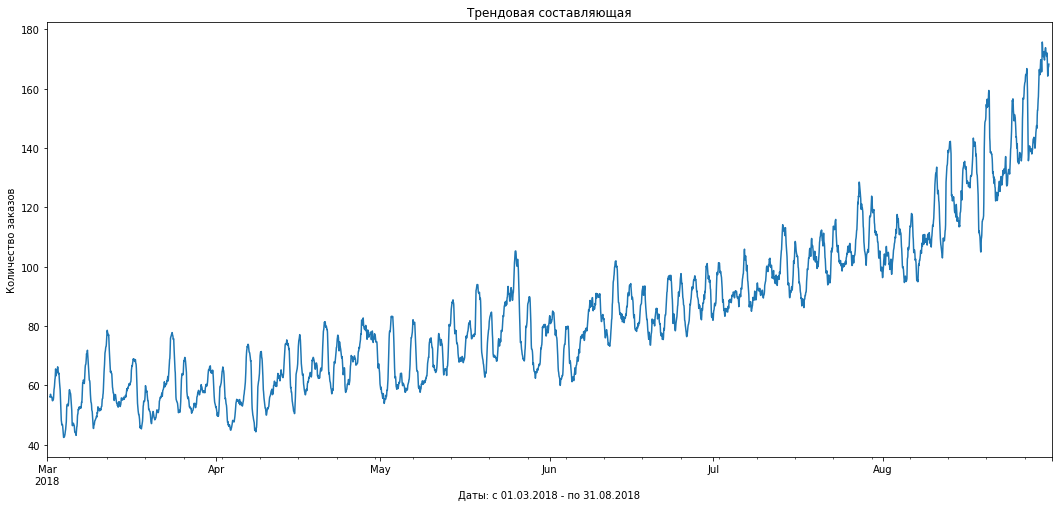

In [11]:
decomposed.trend.plot(figsize=(18, 8))
plt.title('Трендовая составляющая')
plt.xlabel(f'Даты: c {date_min} - по {date_max}')
plt.ylabel('Количество заказов')
plt.show()

Построенный график тренда лишь подтверждает график скользящей средней. В течение года среднее количество заказов за неделю имеет тенденцию к увеличению. К концу рассматриваемого периода (август 2018 года) график достигает своей максимальной отметки.

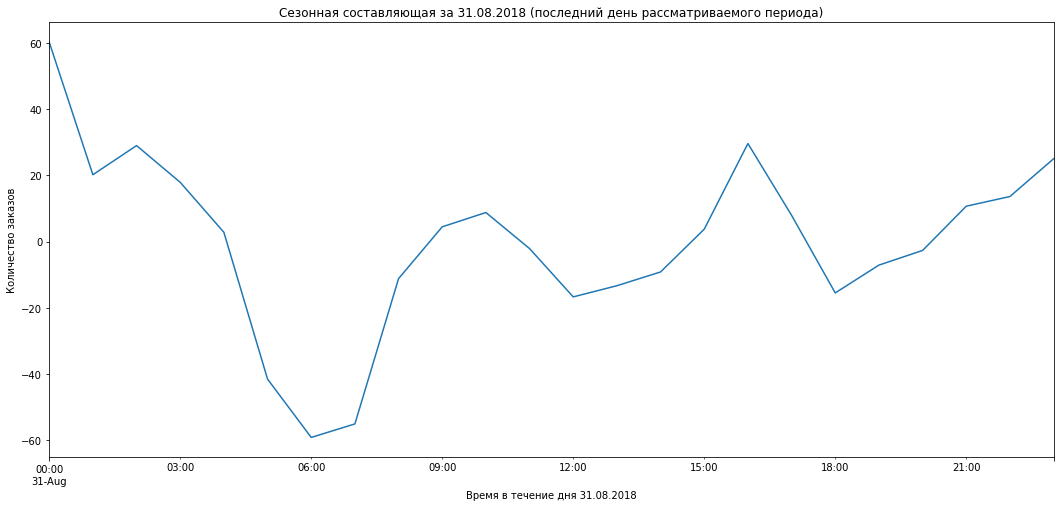

In [12]:
decomposed.seasonal['2018-08-31'].plot(figsize=(18, 8), ax=plt.gca())
plt.title(f'Сезонная составляющая за {date_max} (последний день рассматриваемого периода)')
plt.xlabel(f'Время в течение дня {date_max}')
plt.ylabel('Количество заказов')
plt.show()

График сезонной составляющей показывает наибольшее количество заказов в 00:00 ночью и в 16:00. Наименее редко люди заказывают таким в 6:00 утром.

## Обучение

### Подготовка данных

In [13]:
# Подготовка признаков 
def make_features(data, max_lag):
    # Опережающее значение (целевой признак)
    data['lag_target'] = data['num_orders'].shift(-1)
    
    # Отстающие значения
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)
        
    data['lag_24'] = data['num_orders'].shift(24)
    data['lag_168'] = data['num_orders'].shift(168)

        
    # Календарные признаки
    data['hour'] = data.index.hour
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    # data['week'] = data.index.isocalendar().week
    # data['month'] = data.index.month   
    
    # Скользящие средние
    data['rolling_mean_day'] = data['num_orders'].shift().rolling(24).mean()
    data['rolling_mean_week'] = data['num_orders'].shift().rolling(24 * 7).mean()


make_features(taxi, 10)
taxi = taxi.dropna()

In [14]:
taxi

,num_orders,lag_target,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_24,lag_168,hour,day,dayofweek,rolling_mean_day,rolling_mean_week
datetime,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,78.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,100.0,124.0,0,8,3,60.041667,54.226190
2018-03-08 01:00:00,78,65.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,121.0,85.0,1,8,3,61.833333,54.339286
2018-03-08 02:00:00,65,68.0,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,24.0,71.0,2,8,3,60.041667,54.297619
2018-03-08 03:00:00,68,60.0,65.0,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,66.0,66.0,3,8,3,61.750000,54.261905
2018-03-08 04:00:00,60,6.0,68.0,65.0,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,73.0,43.0,4,8,3,61.833333,54.273810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 18:00:00,207,136.0,217.0,197.0,116.0,133.0,166.0,136.0,167.0,191.0,203.0,182.0,177.0,137.0,18,31,4,163.625000,153.880952
2018-08-31 19:00:00,136,154.0,207.0,217.0,197.0,116.0,133.0,166.0,136.0,167.0,191.0,203.0,72.0,113.0,19,31,4,164.875000,154.297619
2018-08-31 20:00:00,154,159.0,136.0,207.0,217.0,197.0,116.0,133.0,166.0,136.0,167.0,191.0,142.0,179.0,20,31,4,167.541667,154.434524


In [15]:
X = taxi.drop('lag_target', axis=1)
y = taxi['lag_target']

# 10% данных на валидационную и тестовую выборки вместе
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.1)

# 10% данных на тестовую и 10% данных на валидационную выборки
# X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, shuffle=False, test_size=0.5)

In [16]:
X_train.shape

(3822, 18)

In [17]:
y_train.shape

(3822,)

In [18]:
# X_val.shape

In [19]:
# y_val.shape

In [20]:
X_test.shape

(425, 18)

In [21]:
y_test.shape

(425,)

### Подбор параметров

In [22]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3822 entries, 2018-03-08 00:00:00 to 2018-08-14 05:00:00
Freq: H
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   num_orders         3822 non-null   int64  
 1   lag_1              3822 non-null   float64
 2   lag_2              3822 non-null   float64
 3   lag_3              3822 non-null   float64
 4   lag_4              3822 non-null   float64
 5   lag_5              3822 non-null   float64
 6   lag_6              3822 non-null   float64
 7   lag_7              3822 non-null   float64
 8   lag_8              3822 non-null   float64
 9   lag_9              3822 non-null   float64
 10  lag_10             3822 non-null   float64
 11  lag_24             3822 non-null   float64
 12  lag_168            3822 non-null   float64
 13  hour               3822 non-null   int64  
 14  day                3822 non-null   int64  
 15  dayofweek          3822 non-

In [23]:
# Списки столбцов, разделенные по признаку форматирования данных 

# Числовые признаки
num_columns = ['num_orders', 
               'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 
               'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_24', 'lag_168',
               'rolling_mean_day', 'rolling_mean_week']

cat_columns = ['hour', 'day', 'dayofweek']

In [24]:
# Пайплайн подготовки данных для CatBoostRegression и LightGBMRegression

data_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_columns),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_columns)],
      remainder='passthrough') 
                                       

# Итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

In [25]:
# Пайплайн подготовки данных для LinearRegression

data_preprocessor_linear = ColumnTransformer([ 
    ('num', StandardScaler(), num_columns),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_columns)],
      remainder='passthrough')
                                       

# Итоговый пайплайн: подготовка данных и модель
pipe_final_linear = Pipeline([
    ('preprocessor', data_preprocessor_linear),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

In [26]:
# Параметры для LinearRegression
linear_params = {'model': [LinearRegression()]}

# Параметры CatBoostRegression
catboost_params = {'model': [CatBoostRegressor(loss_function='RMSE')],
                   'model__depth': range(4,8),
                   'model__learning_rate': [0.05,0.1]}

# Параметры LightGBMRegression
lgbm_params = {'model': [LGBMRegressor(random_state=RANDOM_STATE, metric='rmse')],
               'model__max_depth': range(4,8),
               'model__learning_rate': [0.05,0.1]}

In [27]:
# Метрика RMSE

def rmse(y_test, y_pred):
    metric = mean_squared_error(y_test, y_pred, squared=False)
    return metric

rmse_score = make_scorer(rmse, greater_is_better=False)

In [28]:
tscv = TimeSeriesSplit(n_splits=5)

In [29]:
# LinearRegression

linear_grid = GridSearchCV(
    pipe_final_linear, 
    linear_params, 
    cv=tscv,
    scoring=rmse_score,
    n_jobs=-1)

linear_grid.fit(X_train, y_train)


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['num_orders',
                                                                          'lag_1',
                                                                          'lag_2',
                                                                          'lag_3',
                                                                          'lag_4',
                                                                          'lag_5',
                                                                          'lag_6',
                                                                          'lag_7',
                                                                          'lag_8',
                                                                          'lag_9',
                                                                          'lag_10',
                                                                          'lag_24',
                                                                          'lag_168',
                                                                          'rolling_mean_day',
                                                                          'rolling_mean_week']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['hour',
                                                                          'day',
                                                                          'dayofweek'])])),
                                       ('model',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1, param_grid={'model': [LinearRegression()]},
             scoring=make_scorer(rmse, greater_is_better=False))

In [30]:
# CatBoostRegression

catboost_grid = GridSearchCV(
    pipe_final, 
    catboost_params, 
    cv=tscv,
    scoring=rmse_score,
    n_jobs=-1)

catboost_grid.fit(X_train, y_train)


0:	learn: 28.9099413	total: 47.7ms	remaining: 47.7s
1:	learn: 28.5325138	total: 48.9ms	remaining: 24.4s
2:	learn: 28.1793106	total: 49.9ms	remaining: 16.6s
3:	learn: 27.6346208	total: 51.1ms	remaining: 12.7s
4:	learn: 27.2045830	total: 52.2ms	remaining: 10.4s
5:	learn: 26.9277311	total: 53.2ms	remaining: 8.81s
6:	learn: 26.6617098	total: 54.3ms	remaining: 7.7s
7:	learn: 26.1896331	total: 55.3ms	remaining: 6.86s
8:	learn: 25.6964466	total: 56.4ms	remaining: 6.21s
9:	learn: 25.3856844	total: 57.3ms	remaining: 5.67s
10:	learn: 25.0959879	total: 58.4ms	remaining: 5.25s
11:	learn: 24.7839734	total: 59.5ms	remaining: 4.9s
12:	learn: 24.5979163	total: 60.5ms	remaining: 4.59s
13:	learn: 24.3245297	total: 61.5ms	remaining: 4.33s
14:	learn: 23.9186706	total: 62.6ms	remaining: 4.11s
15:	learn: 23.7195527	total: 63.5ms	remaining: 3.91s
16:	learn: 23.4938695	total: 64.6ms	remaining: 3.73s
17:	learn: 23.2146888	total: 65.6ms	remaining: 3.58s
18:	learn: 23.0788704	total: 66.7ms	remaining: 3.44s
19:	l

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['num_orders',
                                                                          'lag_1',
                                                                          'lag_2',
                                                                          'lag_3',
                                                                          'lag_4',
                                                                          'lag_5',
                                                                          'lag_6',
                                                                          'lag_7',
                                                                          'lag_8',
                                                                          'lag_9',
                                                                          'lag_10',
                                                                          'lag_24',
                                                                          'lag_168',
                                                                          'rolling_mean_day',
                                                                          'rolling_m...
                                                                        ('cat',
                                                                         OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         ['hour',
                                                                          'day',
                                                                          'dayofweek'])])),
                                       ('model',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model': [<catboost.core.CatBoostRegressor object at 0x7f11853378b0>],
                         'model__depth': range(4, 8),
                         'model__learning_rate': [0.05, 0.1]},
             scoring=make_scorer(rmse, greater_is_better=False))

In [31]:
# LightGBMRegression

lgbm_grid = GridSearchCV(
    pipe_final, 
    lgbm_params, 
    cv=tscv,
    scoring=rmse_score,
    n_jobs=1)

lgbm_grid.fit(X_train, y_train)


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['num_orders',
                                                                          'lag_1',
                                                                          'lag_2',
                                                                          'lag_3',
                                                                          'lag_4',
                                                                          'lag_5',
                                                                          'lag_6',
                                                                          'lag_7',
                                                                          'lag_8',
                                                                          'lag_9',
                                                                          'lag_10',
                                                                          'lag_24',
                                                                          'lag_168',
                                                                          'rolling_mean_day',
                                                                          'rolling_m...
                                                                         OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         ['hour',
                                                                          'day',
                                                                          'dayofweek'])])),
                                       ('model',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=1,
             param_grid={'model': [LGBMRegressor(learning_rate=0.05,
                                                 max_depth=7, metric='rmse',
                                                 random_state=42)],
                         'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': range(4, 8)},
             scoring=make_scorer(rmse, greater_is_better=False))

### LinearRegression

In [32]:
print(f'Параметры модели LinearRegression: {linear_grid.best_params_}')
print(f'Показатель RMSE модели LinearRegression: {linear_grid.best_score_ * -1}')

Параметры модели LinearRegression: {'model': LinearRegression()}
Показатель RMSE модели LinearRegression: 26.555955417214506


### CatBoostRegression

In [33]:
print(f'Параметры лучшей модели CatBoostRegression: {catboost_grid.best_params_}')
print(f'Показатель RMSE модели CatBoostRegression: {catboost_grid.best_score_ * -1}')

Параметры лучшей модели CatBoostRegression: {'model': <catboost.core.CatBoostRegressor object at 0x7f11853378b0>, 'model__depth': 6, 'model__learning_rate': 0.05}
Показатель RMSE модели CatBoostRegression: 25.436625924498603


### LightGBMRegression

In [34]:
print(f'Параметры лучшей модели LightGBMRegression: {lgbm_grid.best_params_}')
print(f'Показатель RMSE модели LightGBMRegression: {lgbm_grid.best_score_ * -1}')

Параметры лучшей модели LightGBMRegression: {'model': LGBMRegressor(learning_rate=0.05, max_depth=7, metric='rmse', random_state=42), 'model__learning_rate': 0.05, 'model__max_depth': 7}
Показатель RMSE модели LightGBMRegression: 24.910261382107386


Результаты моделирования следующие:

Метрика RMSE моделей на валидационной выборке:
- LinearRegression: 26.555955417214506
- CatBoostRegression: 25.436625924498603
- LGBMRegression: 24.910261382107386

Таким образом, по метрике лучше всего проявила себя модель LightGBMRegression. Выбираем ее для дальнейшего тестирования.

## Тестирование

In [35]:
lgbm_test_pred = lgbm_grid.best_estimator_.predict(X_test)
print(f'Показатель RMSE модели LightGBMRegression: {rmse(y_test,lgbm_test_pred)}')

Показатель RMSE модели LightGBMRegression: 43.813945588110705


In [36]:
# Объединим тестовую выборку и наши предсказания
test_taxi = pd.DataFrame(y_test).copy()
test_taxi['pred_orders'] = lgbm_test_pred

In [37]:
test_date_min = test_taxi.index.min().strftime('%d.%m.%Y')
test_date_max = test_taxi.index.max().strftime('%d.%m.%Y')
print(f'Анализируемый период: c {test_date_min} - по {test_date_max}')

Анализируемый период: c 14.08.2018 - по 31.08.2018


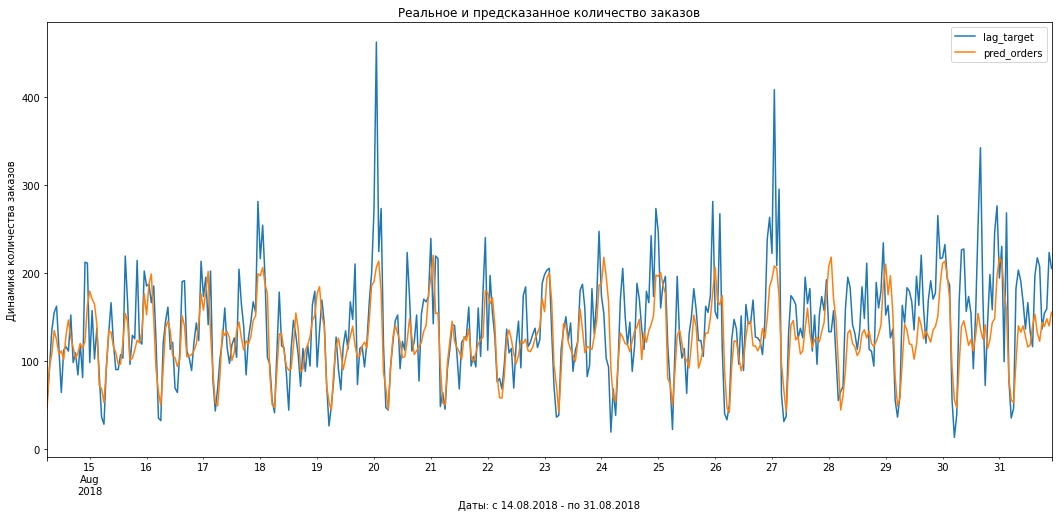

In [39]:
test_taxi.plot(figsize=(18, 8))
plt.title('Реальное и предсказанное количество заказов')
plt.xlabel(f'Даты: c {test_date_min} - по {test_date_max}')
plt.ylabel('Количество заказов')
plt.show()

## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [ ]  Весь код выполняется без ошибок
- [ ]  Ячейки с кодом расположены в порядке исполнения
- [ ]  Данные загружены и подготовлены
- [ ]  Данные проанализированы
- [ ]  Модель обучена, гиперпараметры подобраны
- [ ]  Качество моделей проверено, выводы сделаны
- [ ]  Значение *RMSE* на тестовой выборке не больше 48